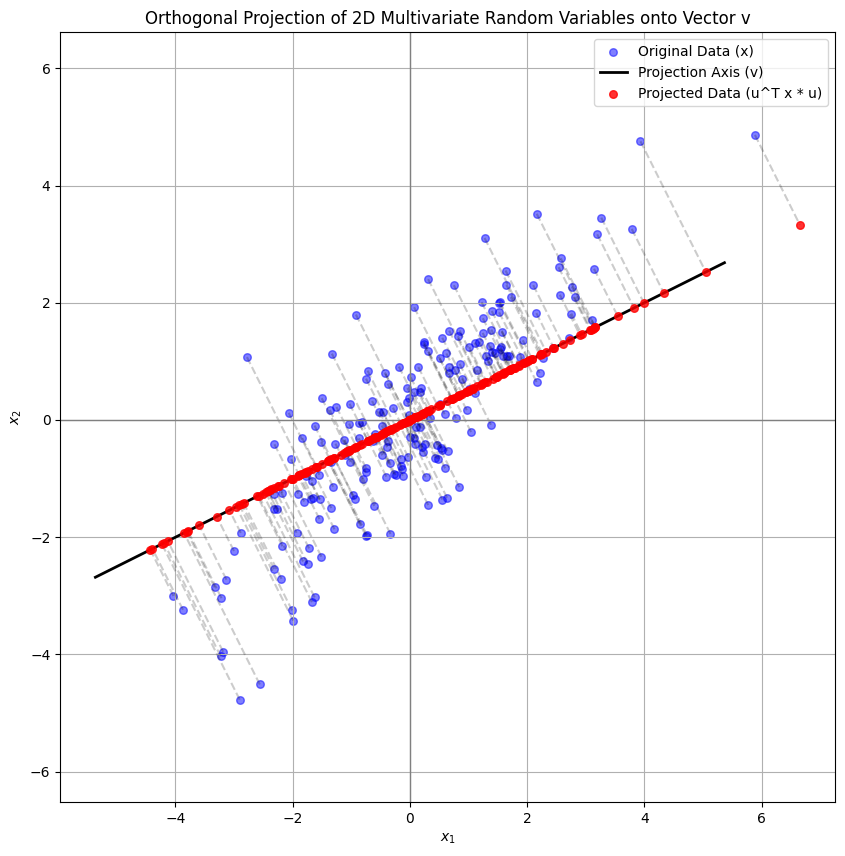

In [1]:
'''
다차원 확률 변수 x의 벡터 v 위로의 정사영(Projection) 시각화 코드
- x_1과 x_2가 서로 비례하는 선형적 관계(양의 상관관계)를 가지도록 공분산 행렬을 설정했습니다.
- 다변량 정규분포에서 200개의 샘플을 추출했습니다.
- 임의의 벡터 v (여기서는 [1, 0.5])가 만드는 1차원 직선을 정의하고, 방향 단위 벡터 u로 정규화했습니다.
- 각 2차원 데이터 점들을 1차원 직선 v 위로 내적을 통해 정사영시키고, 그 위치를 시각화했습니다.
- 원래의 점과 정사영된 점 사이를 점선으로 연결하여 수직으로 투영되는 기하학적 과정을 명확히 보여줍니다.
- 이전 대화에서 논의된 '내적을 통한 새로운 스칼라 확률 변수의 생성'을 코드의 np.dot(X, u)로 직접 구현했습니다.
'''

import numpy as np
import matplotlib.pyplot as plt

# 랜덤 시드 고정
np.random.seed(42)

# 1. 2차원 다변량 정규분포 샘플링 (양의 상관관계)
mean = [0, 0]
cov = [[3.0, 2.5], 
       [2.5, 3.0]]  # x_1과 x_2가 강한 선형 비례 관계를 가짐
num_samples = 200
X = np.random.multivariate_normal(mean, cov, num_samples) # 형태: (200, 2)

# 2. 임의의 1차원 투영 축 v 정의
v = np.array([1.0, 0.5]) # 임의의 벡터
u = v / np.linalg.norm(v) # 방향을 나타내는 단위 벡터로 정규화

# 3. 정사영(Projection) 계산
# X와 u의 내적을 통해 1차원 스칼라 확률 변수 y = u^T x 를 계산
y = np.dot(X, u) 

# 투영된 점들의 2차원 공간 상 좌표 계산
X_projected = np.outer(y, u)

# 4. 시각화
plt.figure(figsize=(10, 10))

# 원본 데이터 스캐터 플롯
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data (x)', color='blue', s=30)

# 투영 축 v가 그리는 1차원 직선
t = np.linspace(-6, 6, 100)
line_x = t * u[0]
line_y = t * u[1]
plt.plot(line_x, line_y, color='black', linewidth=2, label='Projection Axis (v)')

# 투영된 데이터 스캐터 플롯
plt.scatter(X_projected[:, 0], X_projected[:, 1], color='red', alpha=0.8, label='Projected Data (u^T x * u)', s=30, zorder=5)

# 원본 데이터와 투영된 데이터를 잇는 점선 (정사영 과정)
for i in range(num_samples):
    plt.plot([X[i, 0], X_projected[i, 0]], [X[i, 1], X_projected[i, 1]], 'k--', alpha=0.2)

plt.axis('equal') # 직교성을 시각적으로 왜곡 없이 보여주기 위해 필수
plt.grid(True)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Orthogonal Projection of 2D Multivariate Random Variables onto Vector v')
plt.legend()
plt.savefig('projection_visualization.png')

방향 벡터 v: [0.9486833  0.31622777]
공분산 행렬의 이차 형식 (이론적 분산 v^T * Sigma * v): 1.4800
정사영된 1차원 데이터들의 실제 분산 (경험적 분산): 1.0980


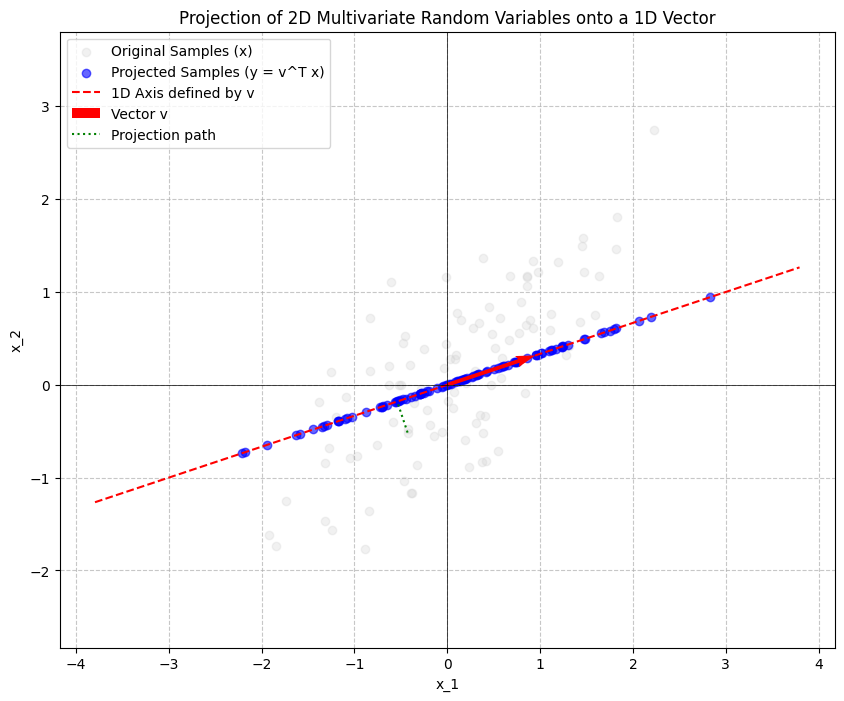

In [7]:
import numpy as np
import matplotlib.pyplot as plt

'''
이 코드는 2차원 다변량 정규분포에서 양의 상관관계를 가지는 확률 변수 x1, x2를 샘플링하고,
이를 임의의 단위 벡터 v가 span하는 1차원 직선 위로 정사영(Projection)하는 과정을 시각화합니다.
이전 대화와의 연결점: 이론적으로 증명했던 '정사영된 1차원 데이터의 분산(경험적 분산)'과 
'공분산 행렬의 이차 형식 v^T * Sigma * v (이론적 분산)'이 실제로 일치하는지를
파이썬을 통해 수치적으로 직접 검증하는 검증부가 추가로 구현되었습니다.
'''

# 1. 평균 벡터와 공분산 행렬 정의
mu = np.array([0, 0])
# x1과 x2가 강한 양의 선형 비례 관계를 갖도록 교차 공분산을 0.8로 설정
cov_matrix = np.array([[1.0, 0.8], 
                       [0.8, 1.0]])

# 2. 다변량 가우시안 분포로부터 1000개의 샘플 데이터 추출
N_samples = 100
np.random.seed(42) # 재현성을 위한 시드 고정
X = np.random.multivariate_normal(mu, cov_matrix, N_samples)

# 3. 투영할 임의의 방향 벡터 v 설정 및 정규화 (단위 벡터화)
# 벡터의 길이가 1이어야 순수한 '분산'을 측정할 수 있으므로 정규화가 필수적임
v_raw = np.array([1.5, 0.5])
v = v_raw / np.linalg.norm(v_raw)

# 4. 벡터 v 위로의 정사영 (1차원 스칼라 확률 변수 생성)
# X 행렬(1000x2)과 열벡터 v(2x1)의 내적을 통해 1차원 스칼라 변수 y 배열(1000,) 생성
y_scalar = X @ v

# 2차원 평면에 정사영된 점들을 시각화하기 위해, 스칼라 값 y를 방향 벡터 v에 다시 곱함
X_projected = np.outer(y_scalar, v)

# 5. 수학적 정리 검증: 이론적 이차 형식 vs 경험적 분산
theoretical_variance = v.T @ cov_matrix @ v
empirical_variance = np.var(y_scalar)

print(f"방향 벡터 v: {v}")
print(f"공분산 행렬의 이차 형식 (이론적 분산 v^T * Sigma * v): {theoretical_variance:.4f}")
print(f"정사영된 1차원 데이터들의 실제 분산 (경험적 분산): {empirical_variance:.4f}")

# 6. 시각화
plt.figure(figsize=(10, 8))

# 원본 2차원 데이터 산점도
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Original Samples (x)', color='lightgray')

# 정사영된 1차원 데이터 산점도 (v축 위)
plt.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.6, label='Projected Samples (y = v^T x)', color='blue')

# 방향 벡터 v가 span하는 1차원 축 그리기
t = np.linspace(-4, 4, 100)
line_points = np.outer(t, v)
plt.plot(line_points[:, 0], line_points[:, 1], color='red', linestyle='--', label='1D Axis defined by v')

# 벡터 v를 화살표로 명시
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Vector v')

# 원본 데이터 점 하나에서 정사영되는 수직선 하나 그리기 (예시)
sample_idx = 0
plt.plot([X[sample_idx, 0], X_projected[sample_idx, 0]], 
         [X[sample_idx, 1], X_projected[sample_idx, 1]], 
         color='green', linestyle=':', label='Projection path')

plt.title('Projection of 2D Multivariate Random Variables onto a 1D Vector')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.legend()
plt.show()

샘플을 키울수록 경험적 분산이 모분산에 수렴하는 것을 볼 수 있음.

방향 벡터 v: [0.9486833  0.31622777]
공분산 행렬의 이차 형식 (이론적 분산 v^T * Sigma * v): 1.4800
정사영된 1차원 데이터들의 실제 분산 (경험적 분산): 1.4859


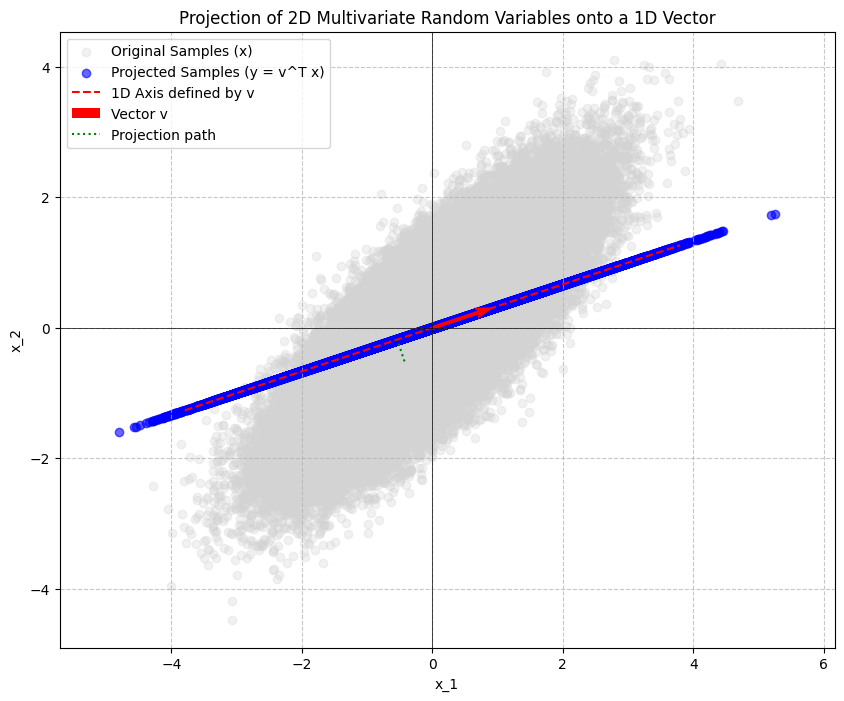

In [8]:
import numpy as np
import matplotlib.pyplot as plt

'''
이 코드는 2차원 다변량 정규분포에서 양의 상관관계를 가지는 확률 변수 x1, x2를 샘플링하고,
이를 임의의 단위 벡터 v가 span하는 1차원 직선 위로 정사영(Projection)하는 과정을 시각화합니다.
이전 대화와의 연결점: 이론적으로 증명했던 '정사영된 1차원 데이터의 분산(경험적 분산)'과 
'공분산 행렬의 이차 형식 v^T * Sigma * v (이론적 분산)'이 실제로 일치하는지를
파이썬을 통해 수치적으로 직접 검증하는 검증부가 추가로 구현되었습니다.
'''

# 1. 평균 벡터와 공분산 행렬 정의
mu = np.array([0, 0])
# x1과 x2가 강한 양의 선형 비례 관계를 갖도록 교차 공분산을 0.8로 설정
cov_matrix = np.array([[1.0, 0.8], 
                       [0.8, 1.0]])

# 2. 다변량 가우시안 분포로부터 100000개의 샘플 데이터 추출
N_samples = 100000
np.random.seed(42) # 재현성을 위한 시드 고정
X = np.random.multivariate_normal(mu, cov_matrix, N_samples)

# 3. 투영할 임의의 방향 벡터 v 설정 및 정규화 (단위 벡터화)
# 벡터의 길이가 1이어야 순수한 '분산'을 측정할 수 있으므로 정규화가 필수적임
v_raw = np.array([1.5, 0.5])
v = v_raw / np.linalg.norm(v_raw)

# 4. 벡터 v 위로의 정사영 (1차원 스칼라 확률 변수 생성)
# X 행렬(1000x2)과 열벡터 v(2x1)의 내적을 통해 1차원 스칼라 변수 y 배열(1000,) 생성
y_scalar = X @ v

# 2차원 평면에 정사영된 점들을 시각화하기 위해, 스칼라 값 y를 방향 벡터 v에 다시 곱함
X_projected = np.outer(y_scalar, v)

# 5. 수학적 정리 검증: 이론적 이차 형식 vs 경험적 분산
theoretical_variance = v.T @ cov_matrix @ v
empirical_variance = np.var(y_scalar)

print(f"방향 벡터 v: {v}")
print(f"공분산 행렬의 이차 형식 (이론적 분산 v^T * Sigma * v): {theoretical_variance:.4f}")
print(f"정사영된 1차원 데이터들의 실제 분산 (경험적 분산): {empirical_variance:.4f}")

# 6. 시각화
plt.figure(figsize=(10, 8))

# 원본 2차원 데이터 산점도
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Original Samples (x)', color='lightgray')

# 정사영된 1차원 데이터 산점도 (v축 위)
plt.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.6, label='Projected Samples (y = v^T x)', color='blue')

# 방향 벡터 v가 span하는 1차원 축 그리기
t = np.linspace(-4, 4, 100)
line_points = np.outer(t, v)
plt.plot(line_points[:, 0], line_points[:, 1], color='red', linestyle='--', label='1D Axis defined by v')

# 벡터 v를 화살표로 명시
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Vector v')

# 원본 데이터 점 하나에서 정사영되는 수직선 하나 그리기 (예시)
sample_idx = 0
plt.plot([X[sample_idx, 0], X_projected[sample_idx, 0]], 
         [X[sample_idx, 1], X_projected[sample_idx, 1]], 
         color='green', linestyle=':', label='Projection path')

plt.title('Projection of 2D Multivariate Random Variables onto a 1D Vector')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.legend()
plt.show()